### IMPORT LIBRARY

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    confusion_matrix
)

### LOAD DATASET

In [3]:
df = pd.read_csv("dataset1.csv")

### BASIC INFORMATION OF DATASET

In [4]:
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,no checking account,18,all credits at this bank paid back duly,car (used),1049,unknown/no savings account,< 1 yr,< 20,female : non-single or male : single,none,...,car or other,21,none,for free,1,skilled employee/official,0 to 2,no,no,good
1,no checking account,9,all credits at this bank paid back duly,others,2799,unknown/no savings account,1 <= ... < 4 yrs,25 <= ... < 35,male : married/widowed,none,...,unknown / no property,36,none,for free,3-Feb,skilled employee/official,3 or more,no,no,good
2,... < 0 DM,12,no credits taken/all credits paid back duly,retraining,841,... < 100 DM,4 <= ... < 7 yrs,25 <= ... < 35,female : non-single or male : single,none,...,unknown / no property,23,none,for free,1,unskilled - resident,0 to 2,no,no,good
3,no checking account,12,all credits at this bank paid back duly,others,2122,unknown/no savings account,1 <= ... < 4 yrs,20 <= ... < 25,male : married/widowed,none,...,unknown / no property,39,none,for free,3-Feb,unskilled - resident,3 or more,no,yes,good
4,no checking account,12,all credits at this bank paid back duly,others,2171,unknown/no savings account,1 <= ... < 4 yrs,< 20,male : married/widowed,none,...,car or other,38,bank,rent,3-Feb,unskilled - resident,0 to 2,no,yes,good


In [5]:
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,no checking account,18,all credits at this bank paid back duly,car (used),1049,unknown/no savings account,< 1 yr,< 20,female : non-single or male : single,none,...,car or other,21,none,for free,1,skilled employee/official,0 to 2,no,no,good
1,no checking account,9,all credits at this bank paid back duly,others,2799,unknown/no savings account,1 <= ... < 4 yrs,25 <= ... < 35,male : married/widowed,none,...,unknown / no property,36,none,for free,3-Feb,skilled employee/official,3 or more,no,no,good
2,... < 0 DM,12,no credits taken/all credits paid back duly,retraining,841,... < 100 DM,4 <= ... < 7 yrs,25 <= ... < 35,female : non-single or male : single,none,...,unknown / no property,23,none,for free,1,unskilled - resident,0 to 2,no,no,good
3,no checking account,12,all credits at this bank paid back duly,others,2122,unknown/no savings account,1 <= ... < 4 yrs,20 <= ... < 25,male : married/widowed,none,...,unknown / no property,39,none,for free,3-Feb,unskilled - resident,3 or more,no,yes,good
4,no checking account,12,all credits at this bank paid back duly,others,2171,unknown/no savings account,1 <= ... < 4 yrs,< 20,male : married/widowed,none,...,car or other,38,bank,rent,3-Feb,unskilled - resident,0 to 2,no,yes,good


In [6]:
df.shape

(1000, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   object
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   object
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [8]:
df.describe()

,duration,amount,age
count,1000.000000,1000.00000,1000.00000
mean,20.903000,3271.24800,35.54200
std,12.058814,2822.75176,11.35267
min,4.000000,250.00000,19.00000
25%,12.000000,1365.50000,27.00000
50%,18.000000,2319.50000,33.00000
75%,24.000000,3972.25000,42.00000
max,72.000000,18424.00000,75.00000


In [9]:
df.isnull().sum()

status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

In [10]:
df["credit_risk"].value_counts()

good    700
bad     300
Name: credit_risk, dtype: int64

### EXPLORATORY DATA ANALYSIS

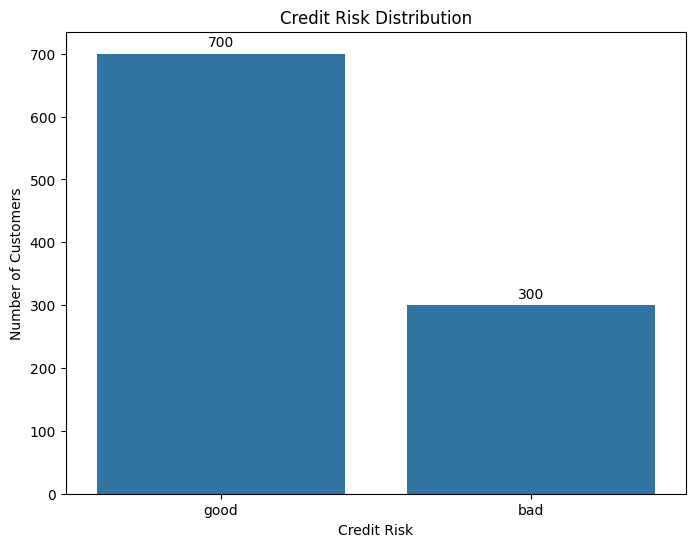

In [11]:
plt.figure(figsize=(8,6))

ax = sns.countplot(data=df, x="credit_risk")

plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.show()

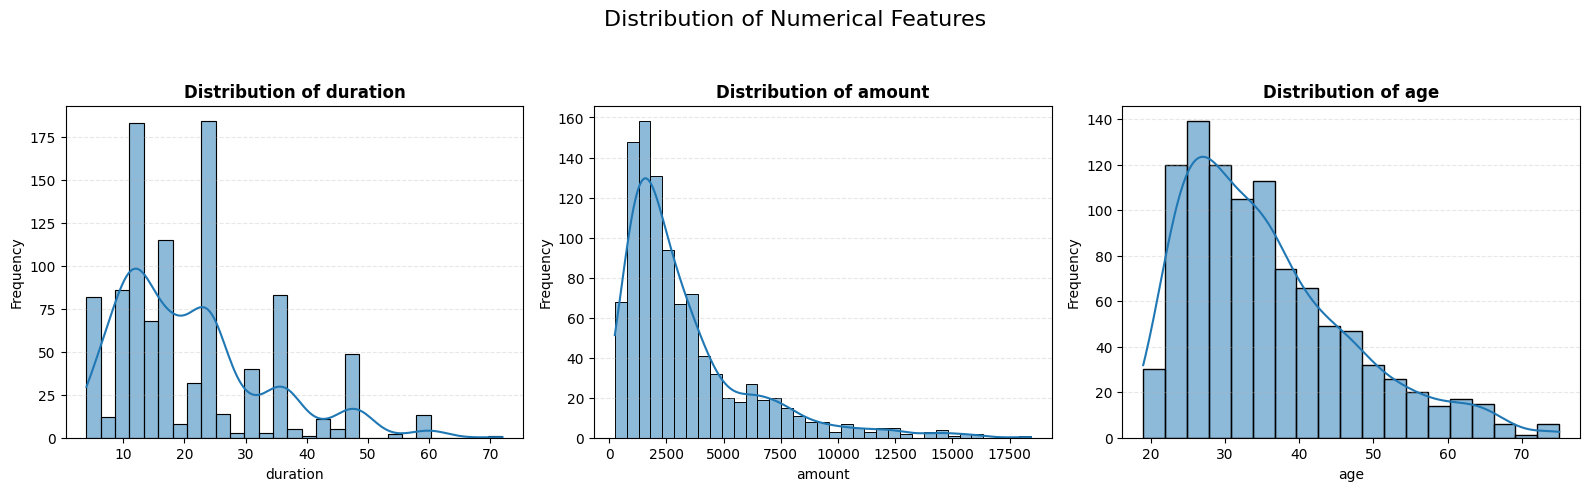

In [12]:
numeric_cols = df.select_dtypes(include="number").columns

# histogram
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(16, 12)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Distribution of {col}",
        fontsize=12,
        fontweight="bold"
    )

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

    axes[i].grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

# atikan subplot yang tidak terpakai
for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

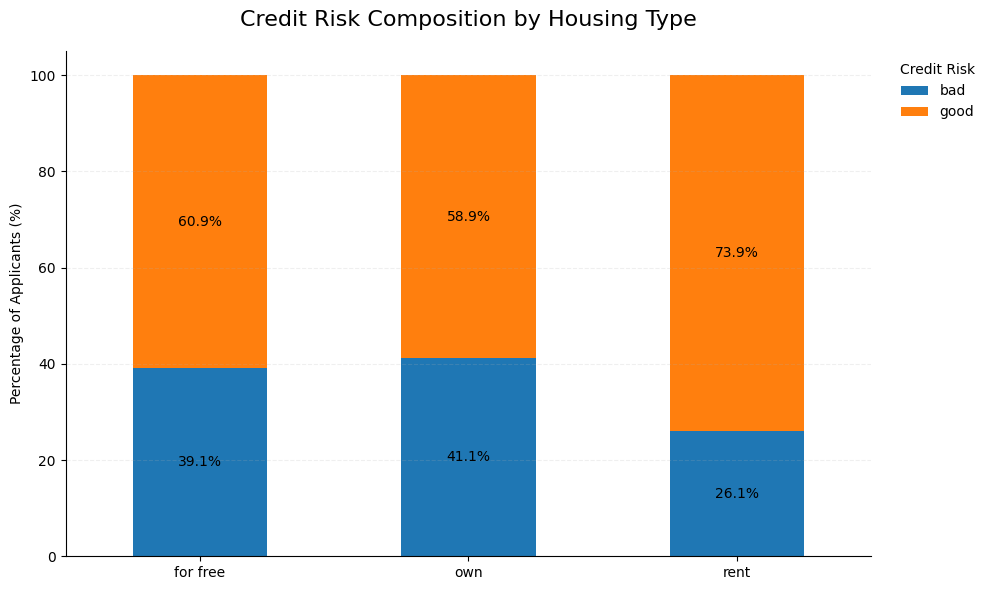

In [13]:
risk_rate = pd.crosstab(
    df["housing"],
    df["credit_risk"],
    normalize="index"
) * 100

ax = risk_rate.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

# Label persentase
for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%"
        if bar.get_height() >= 5 else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=10,
    )

plt.title(
    "Credit Risk Composition by Housing Type",
    fontsize=16,
    pad=18
)

plt.xlabel("")
plt.ylabel("Percentage of Applicants (%)")

plt.xticks(rotation=0)

plt.legend(
    title="Credit Risk",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

sns.despine()

plt.tight_layout()
plt.show()

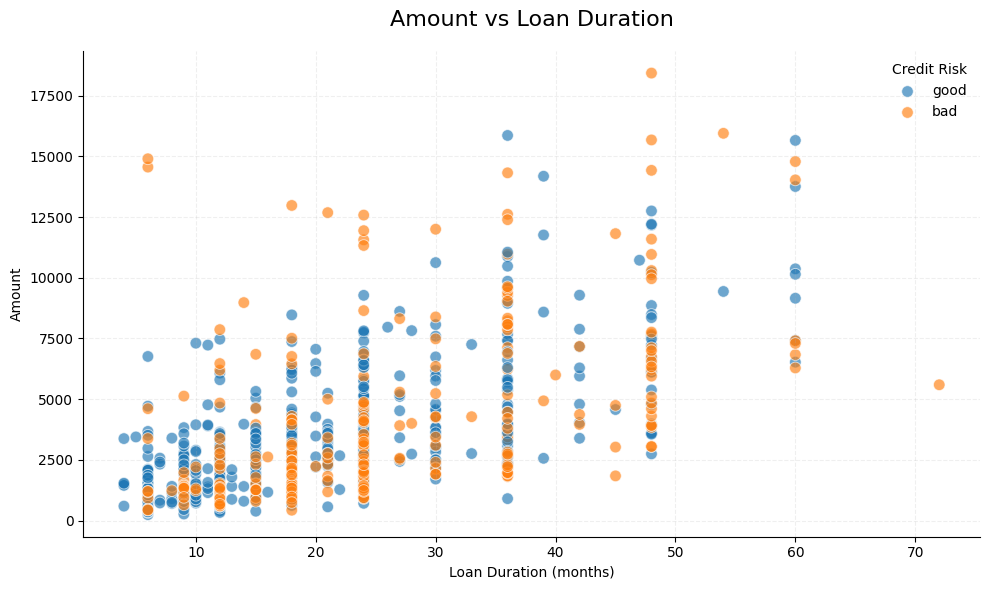

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="duration",
    y="amount",
    hue="credit_risk",
    alpha=0.65,
    s=70
)

plt.title(
    "Amount vs Loan Duration",
    fontsize=16,
    pad=18
)

plt.xlabel("Loan Duration (months)")
plt.ylabel("Amount")

plt.grid(
    linestyle="--",
    alpha=0.2
)

plt.legend(
    title="Credit Risk",
    frameon=False
)

sns.despine()

plt.tight_layout()
plt.show()

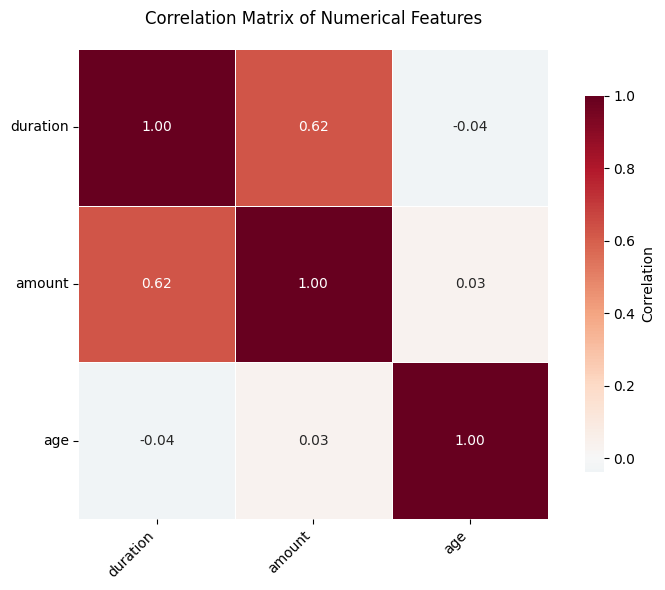

In [15]:
corr = df.select_dtypes(
    include="number"
).corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={
        "shrink": 0.8,
        "label": "Correlation"
    }
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=12,
    pad=18
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

EDA
│
├── 1. Credit Risk Distribution
│       └── Count + Percentage
│
├── 2. Numerical Features
│       └── Histogram + KDE + Median
│
├── 3. Credit Amount & Duration
│       └── Boxplot + Individual Observations
│
├── 4. Categorical Features
│       └── 100% Stacked Bar
│
├── 5. Credit Amount vs Duration
│       └── Scatter + Risk
│
├── 6. Correlation
│       └── Heatmap
│
└── 7. Missing Values
        └── Horizontal Bar + Percentage

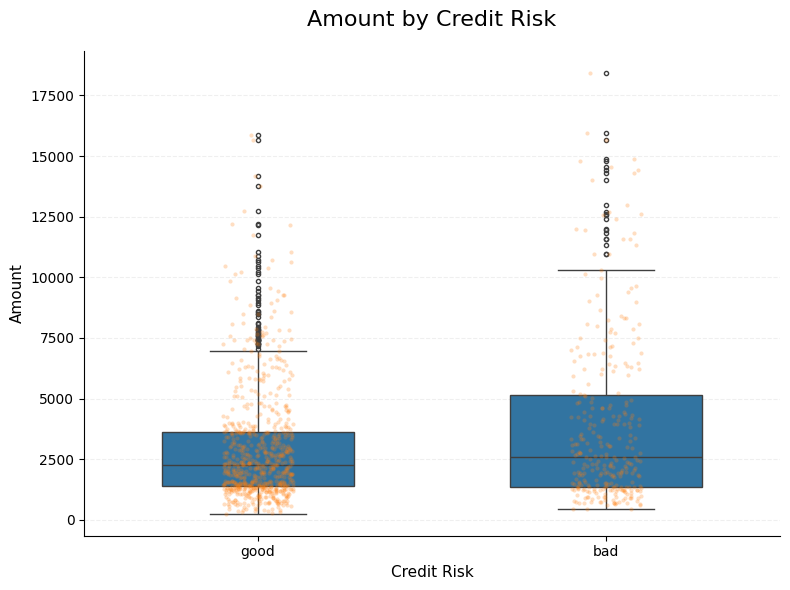

In [16]:
# analysis of the relationship between Features and the Target

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="credit_risk",
    y="amount",
    width=0.55,
    fliersize=3
)

sns.stripplot(
    data=df,
    x="credit_risk",
    y="amount",
    size=3,
    alpha=0.25,
    jitter=True
)

plt.title(
    "Amount by Credit Risk",
    fontsize=16,
    pad=18
)

plt.xlabel("Credit Risk", fontsize=11)
plt.ylabel("Amount", fontsize=11)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

sns.despine()

plt.tight_layout()
plt.show()

#### X and y

In [17]:
X = df.drop("credit_risk", axis=1)
y = df["credit_risk"]

In [18]:
# check the shape of X and y
X.shape, y.shape

((1000, 20), (1000,))

#### spitling the dataset into training and testing sets

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state = 42,
stratify=y
)

#### PREPROCESSING

In [20]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

In [21]:
print("Categorical:", list(categorical_features))
print("Numerical:", list(numerical_features))

Categorical: ['status', 'credit_history', 'purpose', 'savings', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors', 'present_residence', 'property', 'other_installment_plans', 'housing', 'number_credits', 'job', 'people_liable', 'telephone', 'foreign_worker']
Numerical: ['duration', 'amount', 'age']


#### MAKING PIPELINE

In [22]:
# numeric categorical transformer

numeric_transformer = StandardScaler()

In [23]:
# # categorical transformer

categorical_transformer = OneHotEncoder(
    handle_unknown = 'ignore'
)

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            numerical_features
        ),
        (
            'cat',
            categorical_transformer,
            categorical_features
        )
    ]
)

#### USING LOGISTIC REGRESSION MODEL

In [25]:
logistic_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000
        ))
    ]
)

In [26]:
#training

logistic_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['duration', 'amount', 'age'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['status', 'credit_history', 'purpose', 'savings', 'employment_duration',
       'installment_rate', 'personal_status_sex', 'other_debtors',
       'present_residence', 'property', 'other_installment_plans', 'housing',
       'number_credits', 'job', 'people_liable', 'telephone',
       'foreign_worker'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [27]:
#prediction
y_pred = logistic_pipeline.predict(X_test)

In [28]:
#probability
y_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

#### EVALUATION

In [29]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label="bad"
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label="bad"
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="bad"
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.79
Precision: 0.6730769230769231
Recall   : 0.5833333333333334
F1 Score : 0.6250000000000001


In [30]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

Accuracy : 0.79
Precision: 0.6730769230769231
Recall   : 0.5833333333333334
F1 Score : 0.6250000000000001
ROC-AUC  : 0.8247619047619048


In [31]:
def evaluate_model(model, X_test, y_test):
    
    # Prediction
    y_pred = model.predict(X_test)
    
    # Probability
    y_proba = model.predict_proba(X_test)
    
    # Cari posisi class "bad"
    bad_index = list(model.classes_).index("bad")
    
    # Probability untuk "bad"
    y_proba_bad = y_proba[:, bad_index]
    
    # Convert target menjadi binary
    y_test_binary = (y_test == "bad").astype(int)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    precision = precision_score(
        y_test,
        y_pred,
        pos_label="bad"
    )
    
    recall = recall_score(
        y_test,
        y_pred,
        pos_label="bad"
    )
    
    f1 = f1_score(
        y_test,
        y_pred,
        pos_label="bad"
    )
    
    roc_auc = roc_auc_score(
        y_test_binary,
        y_proba_bad
    )
    
    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [32]:
logistic_results = evaluate_model(
    logistic_pipeline,
    X_test,
    y_test
)

logistic_results

{'Accuracy': 0.79,
 'Precision': 0.6730769230769231,
 'Recall': 0.5833333333333334,
 'F1 Score': 0.6250000000000001,
 'ROC-AUC': 0.8247619047619048}

#### USING RANDOM FOREST MODEL

In [33]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [34]:
#training
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['duration', 'amount', 'age'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['status', 'credit_history', 'purpose', 'savings', 'employment_duration',
       'installment_rate', 'personal_status_sex', 'other_debtors',
       'present_residence', 'property', 'other_installment_plans', 'housing',
       'number_credits', 'job', 'people_liable', 'telephone',
       'foreign_worker'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [35]:
#prediction
rf_pred = rf_pipeline.predict(X_test)

In [36]:
#probability 
rf_proba = rf_pipeline.predict_proba(X_test)

In [37]:
rf_proba_bad = rf_proba[:, 0]

y_test_binary = (y_test == "bad").astype(int)

rf_roc_auc = roc_auc_score(
    y_test_binary,
    rf_proba_bad
)

In [38]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    pos_label="bad"
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    pos_label="bad"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    pos_label="bad"
)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Accuracy : 0.765
Precision: 0.7407407407407407
Recall   : 0.3333333333333333
F1 Score : 0.4597701149425288
ROC-AUC  : 0.8211309523809524


In [39]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

         bad       0.74      0.33      0.46        60
        good       0.77      0.95      0.85       140

    accuracy                           0.77       200
   macro avg       0.75      0.64      0.65       200
weighted avg       0.76      0.77      0.73       200



In [40]:
rf_results = evaluate_model(
    rf_pipeline,
    X_test,
    y_test
)

rf_results

{'Accuracy': 0.765,
 'Precision': 0.7407407407407407,
 'Recall': 0.3333333333333333,
 'F1 Score': 0.4597701149425288,
 'ROC-AUC': 0.8211309523809524}

In [41]:
comparison = pd.DataFrame({
    "Logistic Regression": logistic_results,
    "Random Forest": rf_results
}).T

comparison

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.790,0.673077,0.583333,0.62500,0.824762
Random Forest,0.765,0.740741,0.333333,0.45977,0.821131


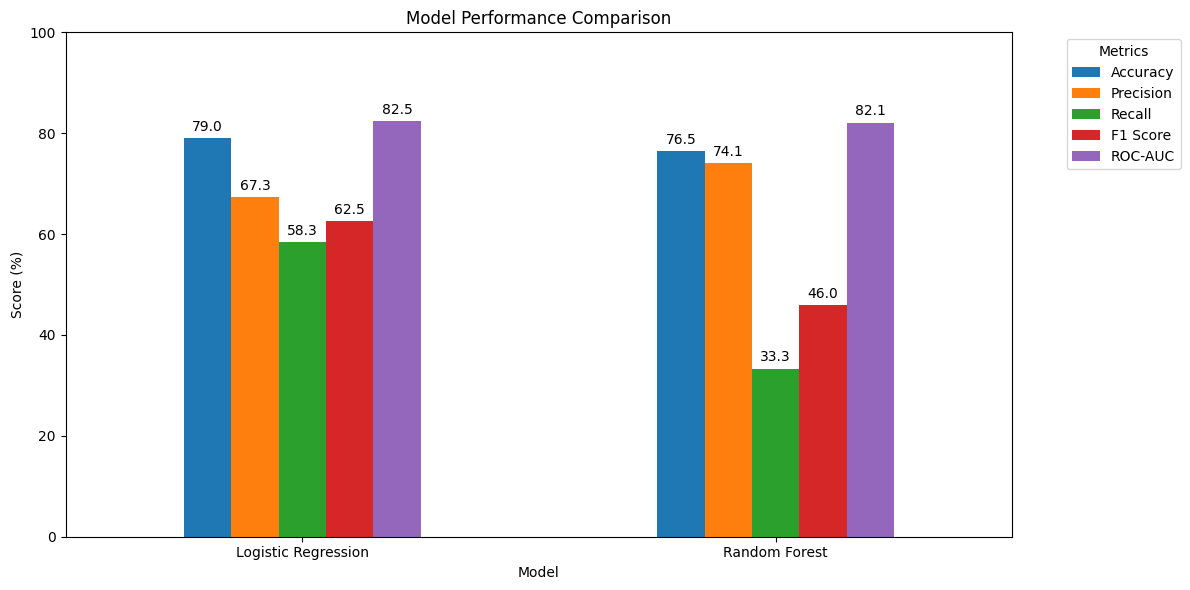

In [42]:
# Ubah score 0-1 menjadi persen
comparison_percent = comparison * 100

# Plot
ax = comparison_percent.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

# Tambahkan angka di atas bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3
    )

plt.tight_layout()
plt.show()

In [43]:
import joblib

joblib.dump(
    logistic_pipeline,
    "credit_risk_model.pkl"
)

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [44]:
logistic_results = evaluate_model(
    logistic_pipeline,
    X_test,
    y_test
)

In [45]:
# ============================================================
# 1. PREDICTION
# ============================================================

y_pred = logistic_pipeline.predict(X_test)

y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]


# ============================================================
# 2. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


# ============================================================
# 3. ROC CURVE
# ============================================================

bad_class_index = list(
    logistic_pipeline.classes_
).index("bad")

y_prob_bad = logistic_pipeline.predict_proba(
    X_test
)[:, bad_class_index]


fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_bad,
    pos_label="bad"
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_bad
    ,
    labels=["good", "bad"]
)


# ============================================================
# 4. EDA SUMMARY
# ============================================================

eda_results = {

    "dataset_shape": df.shape,

    "missing_values": (
        df.isnull()
        .sum()
        .to_dict()
    ),

    "descriptive_statistics": (
        df.describe()
        .to_dict()
    )

}


# ============================================================
# 5. MASUKKAN KE logistic_results
# ============================================================

logistic_results["confusion_matrix"] = cm.tolist()

logistic_results["roc_curve"] = {
    "fpr": fpr.tolist(),
    "tpr": tpr.tolist(),
    "thresholds": thresholds.tolist()
}

logistic_results["roc_auc"] = float(
    roc_auc
)

logistic_results["eda"] = eda_results


logistic_results

{'Accuracy': 0.79,
 'Precision': 0.6730769230769231,
 'Recall': 0.5833333333333334,
 'F1 Score': 0.6250000000000001,
 'ROC-AUC': 0.8247619047619048,
 'confusion_matrix': [[35, 25], [17, 123]],
 'roc_curve': {'fpr': [0.0,
   0.0,
   0.007142857142857143,
   0.007142857142857143,
   0.014285714285714285,
   0.014285714285714285,
   0.02142857142857143,
   0.02142857142857143,
   0.03571428571428571,
   0.03571428571428571,
   0.05,
   0.05,
   0.05714285714285714,
   0.05714285714285714,
   0.07142857142857142,
   0.07142857142857142,
   0.07857142857142857,
   0.07857142857142857,
   0.08571428571428572,
   0.08571428571428572,
   0.09285714285714286,
   0.09285714285714286,
   0.12142857142857143,
   0.12142857142857143,
   0.15714285714285714,
   0.15714285714285714,
   0.16428571428571428,
   0.16428571428571428,
   0.18571428571428572,
   0.18571428571428572,
   0.20714285714285716,
   0.20714285714285716,
   0.21428571428571427,
   0.21428571428571427,
   0.32857142857142857,
   0.

In [46]:
joblib.dump(
    logistic_results,
    "logistic_results.pkl"
)

['logistic_results.pkl']

In [47]:
loaded_results = joblib.load("logistic_results.pkl")

print(loaded_results.keys())

dict_keys(['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'confusion_matrix', 'roc_curve', 'roc_auc', 'eda'])


In [48]:
print(logistic_pipeline.feature_names_in_)

['status' 'duration' 'credit_history' 'purpose' 'amount' 'savings'
 'employment_duration' 'installment_rate' 'personal_status_sex'
 'other_debtors' 'present_residence' 'property' 'age'
 'other_installment_plans' 'housing' 'number_credits' 'job'
 'people_liable' 'telephone' 'foreign_worker']
